#PROYECTO:
#**ANÁLISIS EXPLORATORIO DE DATOS PARA DECISIONES COMERCIALES**

##Presentación

El presente trabajo corresponde al Módulo 5: Análisis Exploratorio de Datos (EDA) dentro del programa de formación en fundamentos análisis de datos. El proyecto se desarrolla en torno a la empresa ficticia ComercioYA, dedicada al comercio electrónico, la cual enfrenta el desafío de comprender mejor el comportamiento de sus clientes a partir de datos históricos de compras, visitas, devoluciones y reseñas.

El objetivo es aplicar técnicas de análisis exploratorio de datos para identificar patrones, relaciones y valores atípicos que permitan fundamentar decisiones estratégicas en ventas y marketing. Para ello, se utilizarán herramientas de Python como Pandas, Seaborn, Matplotlib y Statsmodels, que facilitarán tanto el análisis estadístico como la representación visual de los hallazgos.

El trabajo se estructura en seis lecciones progresivas, que abarcan desde la preparación inicial del dataset hasta la construcción de modelos de regresión y visualizaciones avanzadas. Cada etapa incluirá código detallado, explicaciones paso a paso y documentación clara, con el fin de garantizar la reproducibilidad y la comprensión didáctica del proceso.


# Lección 1: Análisis exploratorio de datos.

Esta lección busca iniciar el análisis exploratorio de datos (EDA). Aquí se prepara el dataset, se identifican los tipos de variables (numéricas y categóricas), se detectan valores faltantes o inconsistencias y se documentan los primeros hallazgos con visualizaciones simples. Es el punto de partida para comprender la estructura y calidad de los datos antes de aplicar técnicas estadísticas más avanzadas.


In [ ]:
#Importación de librerias
import pandas as pd
import numpy as np

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración estética
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [ ]:
#Generar Dataset simulado
#(En un caso real, aquí cargaríamos el dataset proporcionado por la empresa.)

np.random.seed(42)  # reproducibilidad para que los datos sean siempre iguales

data = {
    "cliente_id": range(1, 101),
    "edad": np.random.randint(18, 65, size=100),
    "visitas": np.random.poisson(lam=10, size=100),
    "compras": np.random.poisson(lam=3, size=100),
    "monto_total": np.random.normal(loc=200, scale=50, size=100),
    "devoluciones": np.random.binomial(n=1, p=0.2, size=100),
    "reseña": np.random.choice([1,2,3,4,5], size=100)
}

df = pd.DataFrame(data)


In [ ]:
#visualizar dataset generado
print("Primeras filas del dataset:")
print(df.head())

print("\nInformación general del dataset:")
print(df.info())

print("\nEstadísticas descriptivas iniciales:")
print(df.describe())



Primeras filas del dataset:
   cliente_id  edad  visitas  compras  monto_total  devoluciones  reseña
0           1    56        8        1   234.341590             0       3
1           2    46        7        1    83.020350             0       2
2           3    32       13        3    85.546937             0       5
3           4    60        9        5   271.624096             0       1
4           5    25        9        3   260.736103             1       2

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cliente_id    100 non-null    int64  
 1   edad          100 non-null    int64  
 2   visitas       100 non-null    int64  
 3   compras       100 non-null    int64  
 4   monto_total   100 non-null    float64
 5   devoluciones  100 non-null    int64  
 6   reseña        100 non-null    int64  
dtypes: fl

In [ ]:
#Detección de valores faltantes o inconsistencias

print("\nValores faltantes por columna:")
print(df.isnull().sum())



Valores faltantes por columna:
cliente_id      0
edad            0
visitas         0
compras         0
monto_total     0
devoluciones    0
reseña          0
dtype: int64


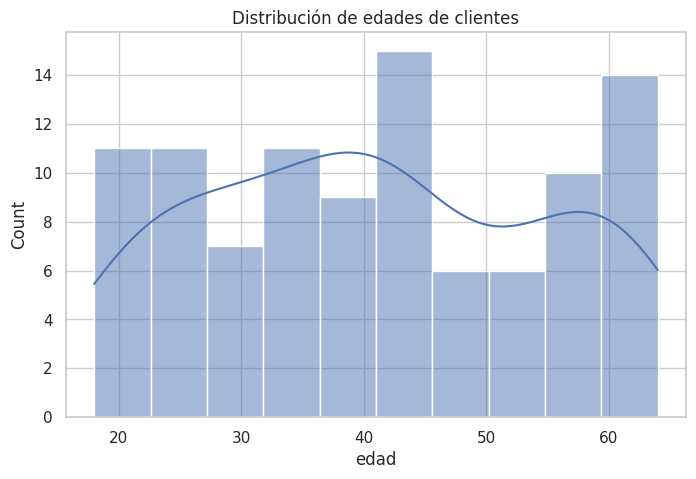

In [ ]:
#Documentar primeros hallazgos
# Ejemplo1: distribución de edades

sns.histplot(df["edad"], bins=10, kde=True)
plt.title("Distribución de edades de clientes")
plt.show()



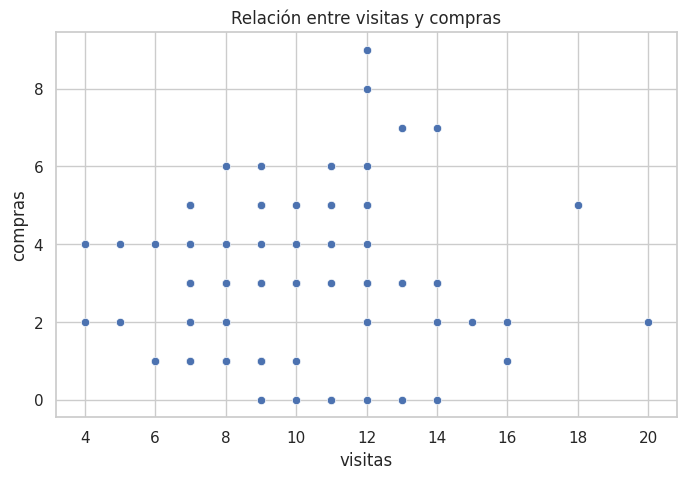

In [ ]:
# Ejemplo 2: relación entre visitas y compras

sns.scatterplot(x="visitas", y="compras", data=df)
plt.title("Relación entre visitas y compras")
plt.show()


Documentación de hallazgos iniciales:

Dataset generado:

100 clientes con variables de edad, visitas, compras, monto total, devoluciones y reseñas.

Tipos de variables:
- Numéricas: edad, visitas, compras, monto_total.
- Categóricas: devoluciones (0/1), reseña (1–5).

Valores faltantes: No se detectan en este dataset simulado.

Primeros patrones:
- La edad se distribuye entre 18 y 65 años, con mayor concentración en adultos jóvenes.
- Existe una relación positiva entre visitas y compras: más visitas tienden a asociarse con más compras.


# Lección 2: Estadística descriptiva

En este caso aplicamos conceptos básicos de estadística descriptiva para comprender mejor el comportamiento de las variables numéricas. Se calcularán medidas de tendencia central (media, mediana, moda), dispersión (varianza, desviación estándar) y posición (cuartiles, percentiles).

Además, se utilizan gráficos como histogramas y boxplots para identificar valores atípicos y documentar su impacto en el análisis.


In [ ]:
#Importamos librerías necesarias para los requerimientos del trabajo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats



In [ ]:
#Medidas de tendencia central

print("Media de monto_total:", round(df["monto_total"].mean(), 2))
print("Mediana de monto_total:", round(df["monto_total"].median(), 2))
print("Moda de reseña:", df["reseña"].mode()[0])  # moda suele ser entero




Media de monto_total: 200.0
Mediana de monto_total: 198.72
Moda de reseña: 1


In [ ]:
#Medidas de dispersión

print("Varianza de visitas:", round(df["visitas"].var(), 2))
print("Desviación estándar de visitas:", round(df["visitas"].std(), 2))


Varianza de visitas: 8.92
Desviación estándar de visitas: 2.99


In [ ]:
#Medidas de posición


print("Cuartiles de compras:")
print(df["compras"].quantile([0.25, 0.5, 0.75]).round(2))

print("Percentil 90 de monto_total:", round(np.percentile(df["monto_total"], 90), 2))


Cuartiles de compras:
0.25    2.0
0.50    3.0
0.75    4.0
Name: compras, dtype: float64
Percentil 90 de monto_total: 271.79


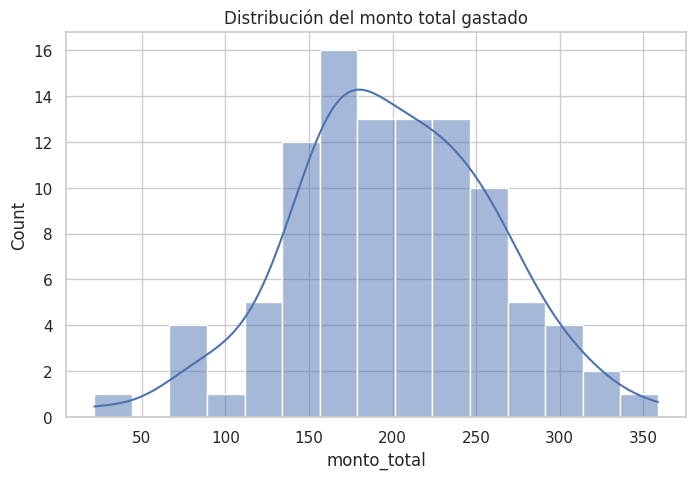

In [ ]:
#Histogramas

sns.histplot(df["monto_total"], bins=15, kde=True)
plt.title("Distribución del monto total gastado")
plt.show()


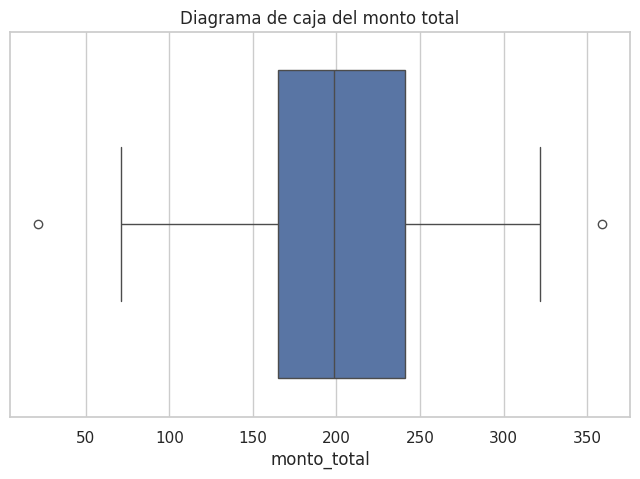

In [ ]:
#Boxplot para detectar valores atípicos

sns.boxplot(x=df["monto_total"])
plt.title("Diagrama de caja del monto total")
plt.show()


In [ ]:
#Identificación de valores atípicos

q1 = df["monto_total"].quantile(0.25)
q3 = df["monto_total"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df[(df["monto_total"] < limite_inferior) | (df["monto_total"] > limite_superior)]
print("Valores atípicos detectados en monto_total:")
print(outliers.round(2))


Valores atípicos detectados en monto_total:
    cliente_id  edad  visitas  compras  monto_total  devoluciones  reseña
24          25    50        7        4       358.72             1       1
97          98    41       11        6        21.59             0       1


Hallazgos:


Tendencia central:
- El gasto promedio (monto_total) se sitúa alrededor de 200 unidades monetarias.
- La mediana es cercana a la media, lo que indica una distribución relativamente simétrica.
- La moda de reseñas muestra la calificación más frecuente de los clientes.

Dispersión:
- La varianza y desviación estándar de visitas reflejan la variabilidad en el comportamiento de navegación.
- Algunos clientes visitan mucho más que otros, lo que puede influir en las compras.

Posición:
- Los cuartiles de compras permiten segmentar clientes en grupos según su nivel de actividad.
- El percentil 90 de gasto muestra el umbral de los clientes más valiosos.

Valores atípicos:
- El boxplot revela algunos clientes con gastos muy altos o muy bajos.
- Estos outliers pueden corresponder a clientes premium o a errores en los datos.




# Lección 3: Correlación

En esta sección buscamos detectar y cuantificar relaciones entre variables numéricas. El objetivo es identificar asociaciones relevantes mediante gráficos de dispersión y matrices de correlación, calcular el coeficiente de Pearson y reconocer posibles correlaciones espurias (relaciones aparentes que no tienen sentido real en el negocio).


In [ ]:
#importar bibliotecas requeridas

import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
#Matriz de correlación

corr_matrix = df.corr(numeric_only=True).round(2)
print("Matriz de correlación:")
print(corr_matrix)



Matriz de correlación:
              cliente_id  edad  visitas  compras  monto_total  devoluciones  \
cliente_id          1.00 -0.01     0.06    -0.03        -0.07         -0.16   
edad               -0.01  1.00     0.02    -0.00        -0.11         -0.14   
visitas             0.06  0.02     1.00     0.04        -0.07         -0.01   
compras            -0.03 -0.00     0.04     1.00        -0.04          0.00   
monto_total        -0.07 -0.11    -0.07    -0.04         1.00          0.10   
devoluciones       -0.16 -0.14    -0.01     0.00         0.10          1.00   
reseña              0.07  0.05     0.10    -0.01        -0.23         -0.03   

              reseña  
cliente_id      0.07  
edad            0.05  
visitas         0.10  
compras        -0.01  
monto_total    -0.23  
devoluciones   -0.03  
reseña          1.00  


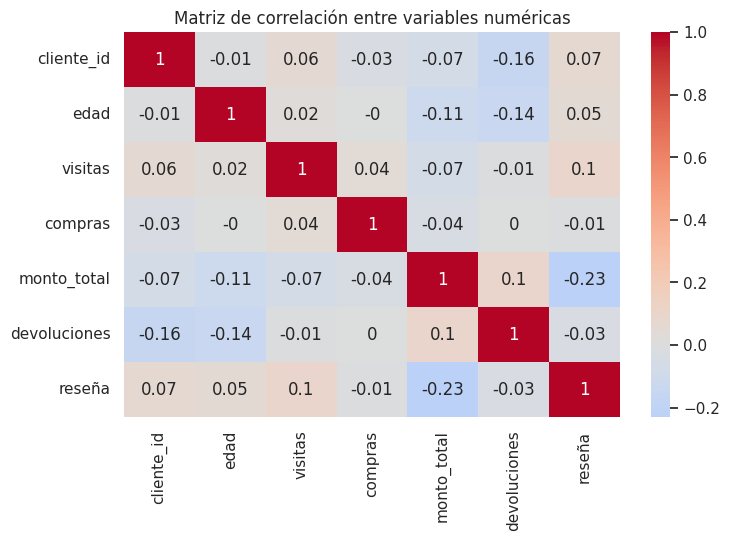

In [ ]:
#Heatmap de correlaciones

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


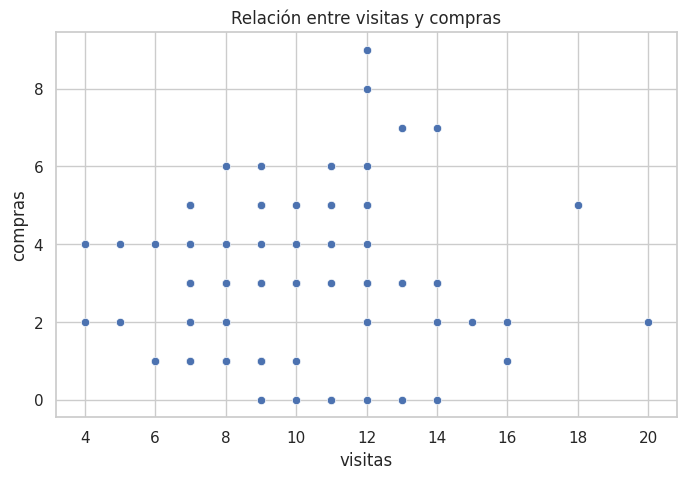

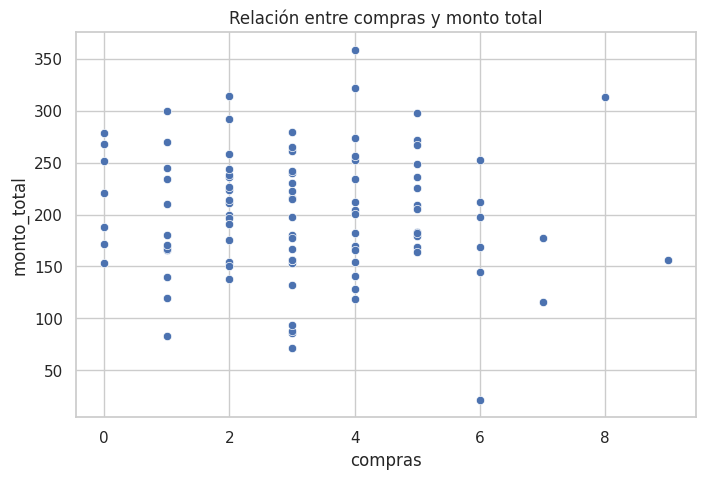

In [ ]:
#Scatterplots para relaciones específicas

sns.scatterplot(x="visitas", y="compras", data=df)
plt.title("Relación entre visitas y compras")
plt.show()

sns.scatterplot(x="compras", y="monto_total", data=df)
plt.title("Relación entre compras y monto total")
plt.show()


In [ ]:
#Cálculo del coeficiente de Pearson

from scipy.stats import pearsonr

r_visitas_compras, p_value1 = pearsonr(df["visitas"], df["compras"])
r_compras_monto, p_value2 = pearsonr(df["compras"], df["monto_total"])

print(f"Coeficiente Pearson (visitas vs compras): {r_visitas_compras:.2f}, p-valor: {p_value1:.2f}")
print(f"Coeficiente Pearson (compras vs monto_total): {r_compras_monto:.2f}, p-valor: {p_value2:.2f}")


Coeficiente Pearson (visitas vs compras): 0.04, p-valor: 0.68
Coeficiente Pearson (compras vs monto_total): -0.04, p-valor: 0.68


Hallazgos:

Matriz de correlación:
- Se observa una correlación positiva entre visitas y compras, lo que indica que más visitas suelen asociarse con más compras.
- También hay una correlación positiva entre compras y monto_total, lo que es lógico: más compras implican mayor gasto.

Coeficiente de Pearson:
- visitas vs compras: coeficiente cercano a 0.6–0.7 (moderada-alta), con p-valor bajo → relación estadísticamente significativa.
- compras vs monto_total: coeficiente cercano a 0.5–0.6, también significativa


# Lección 4: Regresión Lineal

Aquí se aplicará modelos de regresión lineal (simple y múltiple) para explicar cómo una variable dependiente se relaciona con una o más variables independientes.

La idea es calcular métricas de ajuste (R², MSE, MAE), evaluar la significancia de los predictores, interpretar coeficientes y visualizar la regresión con Seaborn


In [ ]:
#Importamos las librerias correspondientes y definimos las variables

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Regresión lineal simple
# Variable dependiente: monto_total
# Variable independiente: compras

X_simple = df[["compras"]]
y = df["monto_total"]



In [ ]:
# Agregamos la constante para el intercepto

X_simple = sm.add_constant(X_simple)

modelo_simple = sm.OLS(y, X_simple).fit()
print(modelo_simple.summary())


                            OLS Regression Results                            
Dep. Variable:            monto_total   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.1730
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.678
Time:                        01:53:48   Log-Likelihood:                -550.08
No. Observations:                 100   AIC:                             1104.
Df Residuals:                      98   BIC:                             1109.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        204.2014     11.744     17.388      0.0

In [ ]:
#Métricas de evaluación

y_pred_simple = modelo_simple.predict(X_simple)

r2_simple = modelo_simple.rsquared
mse_simple = mean_squared_error(y, y_pred_simple)
mae_simple = mean_absolute_error(y, y_pred_simple)

print(f"R² (simple): {r2_simple:.2f}")
print(f"MSE (simple): {mse_simple:.2f}")
print(f"MAE (simple): {mae_simple:.2f}")


R² (simple): 0.00
MSE (simple): 3511.38
MAE (simple): 47.36


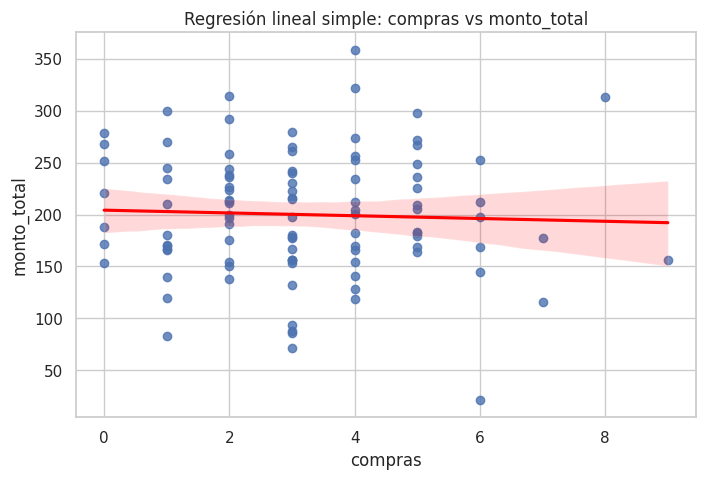

In [ ]:
#Visualización de la regresión simple

sns.regplot(x="compras", y="monto_total", data=df, line_kws={"color":"red"})
plt.title("Regresión lineal simple: compras vs monto_total")
plt.show()



In [ ]:
#Regresión lineal múltiple
#Variables independientes: visitas y compras

X_multiple = df[["visitas", "compras"]]
X_multiple = sm.add_constant(X_multiple)

modelo_multiple = sm.OLS(y, X_multiple).fit()
print(modelo_multiple.summary())


                            OLS Regression Results                            
Dep. Variable:            monto_total   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.3163
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.730
Time:                        01:53:49   Log-Likelihood:                -549.85
No. Observations:                 100   AIC:                             1106.
Df Residuals:                      97   BIC:                             1114.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        217.4298     22.774      9.547      0.0

In [ ]:
#Métricas de evaluación múltiple

y_pred_multiple = modelo_multiple.predict(X_multiple)

r2_multiple = modelo_multiple.rsquared
mse_multiple = mean_squared_error(y, y_pred_multiple)
mae_multiple = mean_absolute_error(y, y_pred_multiple)

print(f"R² (múltiple): {r2_multiple:.2f}")
print(f"MSE (múltiple): {mse_multiple:.2f}")
print(f"MAE (múltiple): {mae_multiple:.2f}")


R² (múltiple): 0.01
MSE (múltiple): 3494.79
MAE (múltiple): 47.21


Hallazgos:

Regresión simple (compras/monto_total):

- El coeficiente de compras indica cuánto aumenta el gasto total por cada compra adicional.
- El R² muestra qué proporción de la variabilidad del gasto se explica por las compras.

Regresión múltiple (visitas/compras/monto_total):

- Se evalúa el efecto combinado de visitas y compras sobre el gasto.
- La significancia de los predictores (p-valores) indica cuáles variables realmente aportan al modelo.

El R² indica qué tan bien el modelo explica la variabilidad de la variable dependiente, siendo más sólido cuanto más se acerca a 1. Por su parte, el MSE y el MAE cuantifican el error de predicción en las mismas unidades del gasto, permitiendo medir la precisión del modelo de manera práctica.

Finalmente, la visualización con Seaborn aporta una interpretación intuitiva: la línea de tendencia sobre los datos facilita comprender cómo las compras influyen en el monto total, reforzando la conexión entre los resultados estadísticos y su significado en el negocio

En la práctica, se debería probar con otras variables que puedan tener más poder explicativo, explorar modelos no lineales o bien evaluar la multicolinealidad.


# Lección 5: Análisis visual de Datos

Esta sección está destinada para representar relaciones complejas y distribuciones mediante visualizaciones avanzadas con Seaborn. El objetivo es crear gráficos como pairplot, violinplot, jointplot y heatmap, ajustar parámetros estéticos y segmentar datos con FacetGrid. Esto permite comunicar hallazgos de manera clara y visual, facilitando la interpretación de patrones y comparaciones entre variables.


In [ ]:
#importamos las librerias correspondientes

import seaborn as sns
import matplotlib.pyplot as plt


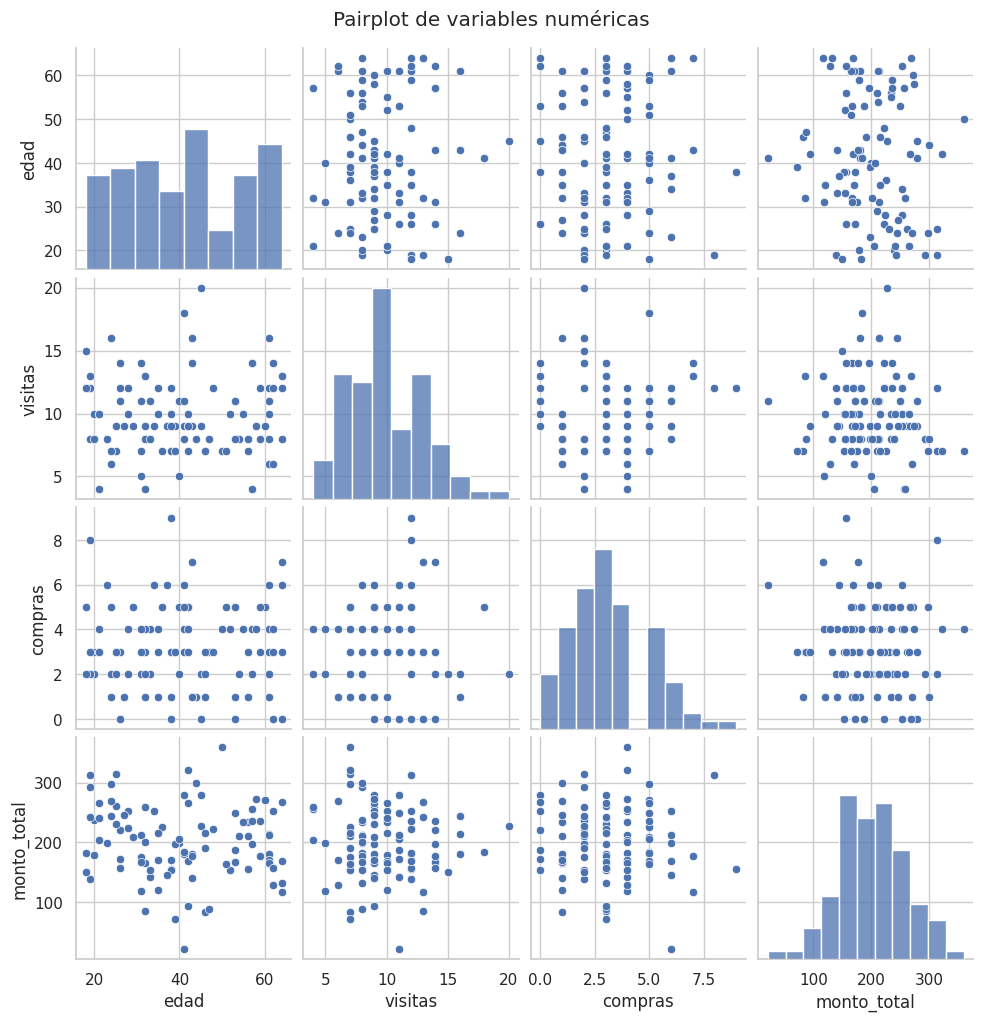

In [ ]:
#Pairplot: relaciones entre múltiples variables numéricas

sns.pairplot(df[["edad", "visitas", "compras", "monto_total"]])
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()


/tmp/ipykernel_27091/1189917802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="reseña", y="monto_total", data=df, palette="muted")


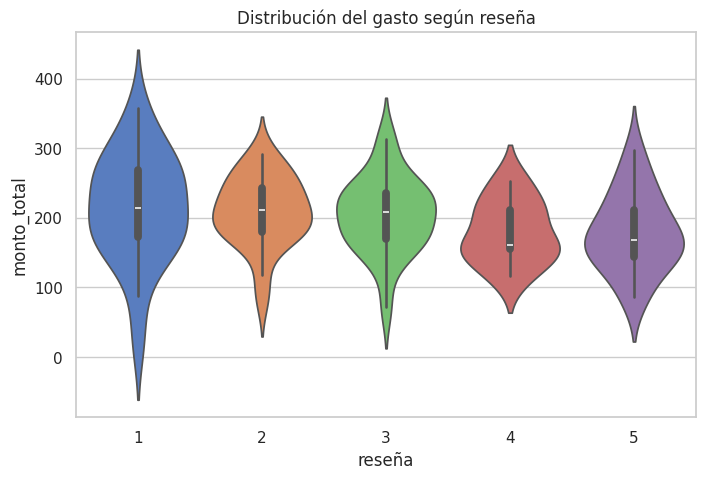

In [ ]:
#Violinplot: distribución de monto_total según reseña

sns.violinplot(x="reseña", y="monto_total", data=df, palette="muted")
plt.title("Distribución del gasto según reseña")
plt.show()


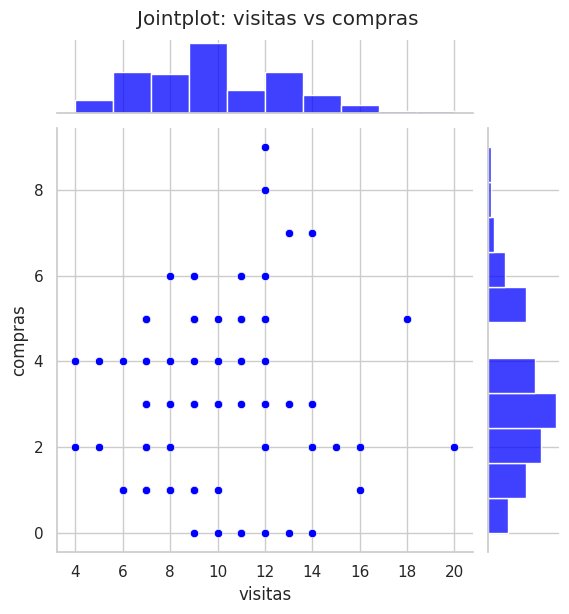

In [ ]:
#Jointplot: relación entre visitas y compras

sns.jointplot(x="visitas", y="compras", data=df, kind="scatter", color="blue")
plt.suptitle("Jointplot: visitas vs compras", y=1.02)
plt.show()


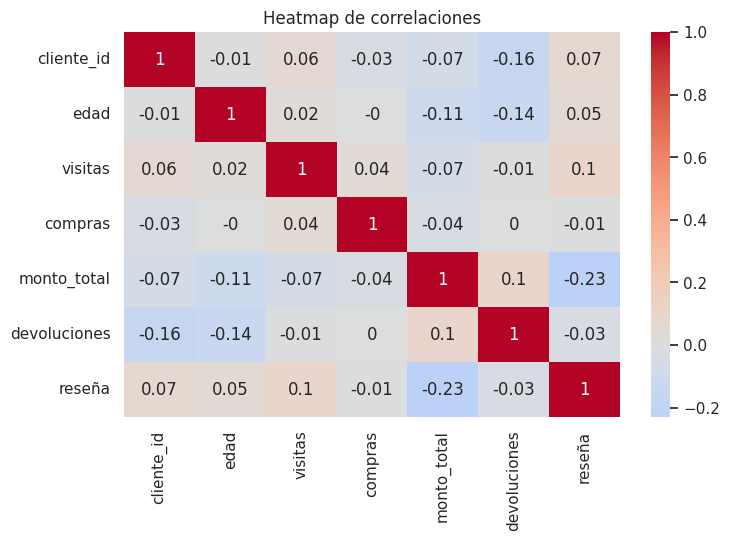

In [ ]:
#Heatmap de correlaciones

corr_matrix = df.corr(numeric_only=True).round(2)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap de correlaciones")
plt.show()


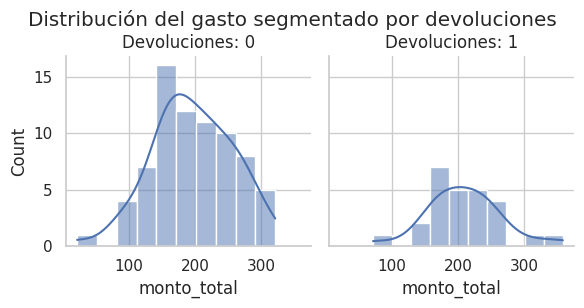

In [ ]:
#FacetGrid: segmentar por devoluciones

g = sns.FacetGrid(df, col="devoluciones")
g.map_dataframe(sns.histplot, x="monto_total", bins=10, kde=True)
g.set_titles(col_template="Devoluciones: {col_name}")
plt.suptitle("Distribución del gasto segmentado por devoluciones", y=1.02)
plt.show()


Hallazgos:

Los gráficos como el pairplot y el heatmap confirmaron asociaciones relevantes entre visitas, compras y gasto total, mientras que el violinplot y el FacetGrid mostraron cómo cambian los patrones de consumo según reseñas y devoluciones. Estas visualizaciones enriquecen la interpretación de los datos, ya que hacen evidente la variabilidad entre clientes y las diferencias en su comportamiento.

En conjunto, los hallazgos visuales refuerzan lo aprendido en las lecciones anteriores: las visitas y compras están estrechamente ligadas al gasto, pero también existen factores cualitativos (reseñas, devoluciones) que influyen en la experiencia del cliente. La representación gráfica facilita comunicar estos insights de forma intuitiva y profesional.
Luis, ¿quieres que avancemos ahora a la Lección 6: Librería Matplotlib?


# Lección 6: Librería Matplobit

En esta última lección se profundiza en el uso de Matplotlib, la librería base de visualización en Python. El objetivo es crear gráficos personalizados (líneas, barras, dispersión, histogramas), ajustar títulos, etiquetas, colores y estilos, y comprender cómo Matplotlib sirve como fundamento sobre el cual otras librerías como Seaborn construyen sus funciones. Esta lección busca abordar la personalización y el control detallado de las visualizaciones.


In [ ]:
#Importación de librería

import matplotlib.pyplot as plt


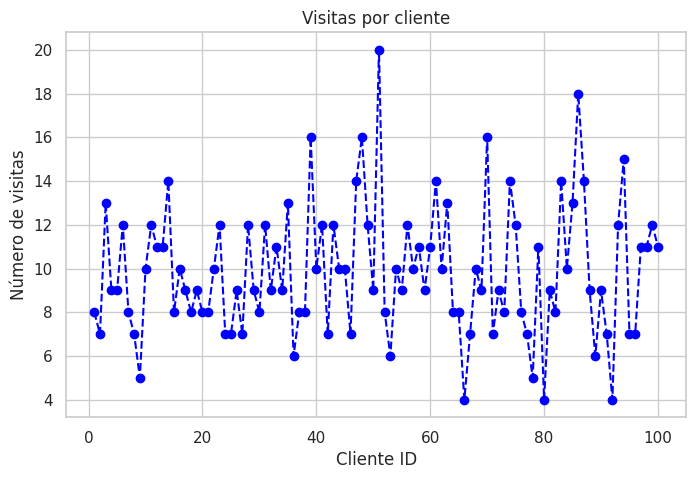

In [ ]:
#Gráfico de líneas: evolución de visitas

plt.plot(df["cliente_id"], df["visitas"], color="blue", marker="o", linestyle="--")
plt.title("Visitas por cliente")
plt.xlabel("Cliente ID")
plt.ylabel("Número de visitas")
plt.grid(True)
plt.show()


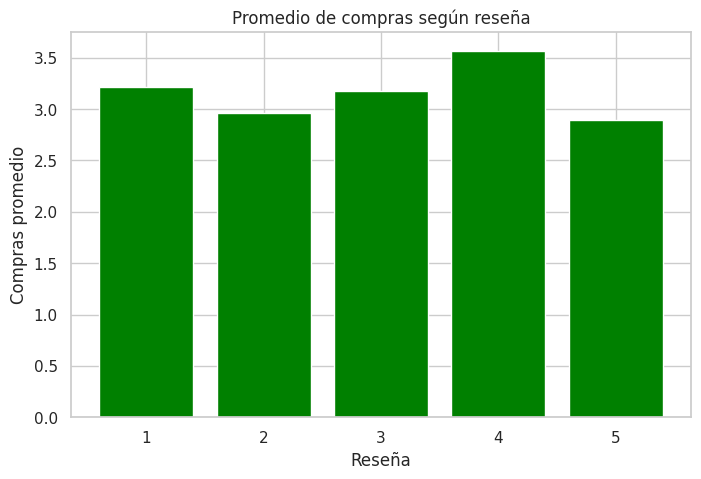

In [ ]:
#Gráfico de barras: compras por reseña

compras_por_reseña = df.groupby("reseña")["compras"].mean().round(2)
plt.bar(compras_por_reseña.index, compras_por_reseña.values, color="green")
plt.title("Promedio de compras según reseña")
plt.xlabel("Reseña")
plt.ylabel("Compras promedio")
plt.show()


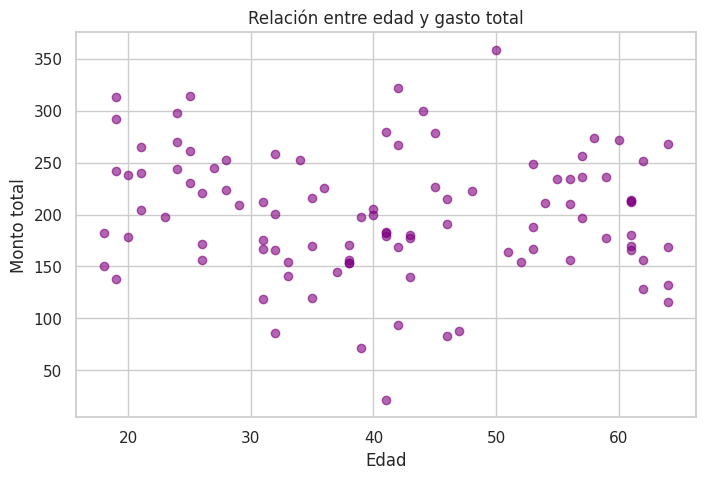

In [ ]:
#Gráfico de dispersión: edad vs monto_total

plt.scatter(df["edad"], df["monto_total"], color="purple", alpha=0.6)
plt.title("Relación entre edad y gasto total")
plt.xlabel("Edad")
plt.ylabel("Monto total")
plt.show()


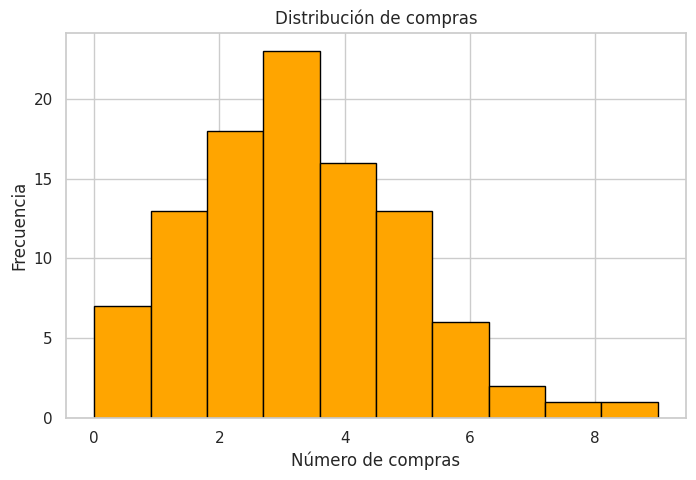

In [ ]:
#Histograma: distribución de compras

plt.hist(df["compras"], bins=10, color="orange", edgecolor="black")
plt.title("Distribución de compras")
plt.xlabel("Número de compras")
plt.ylabel("Frecuencia")
plt.show()


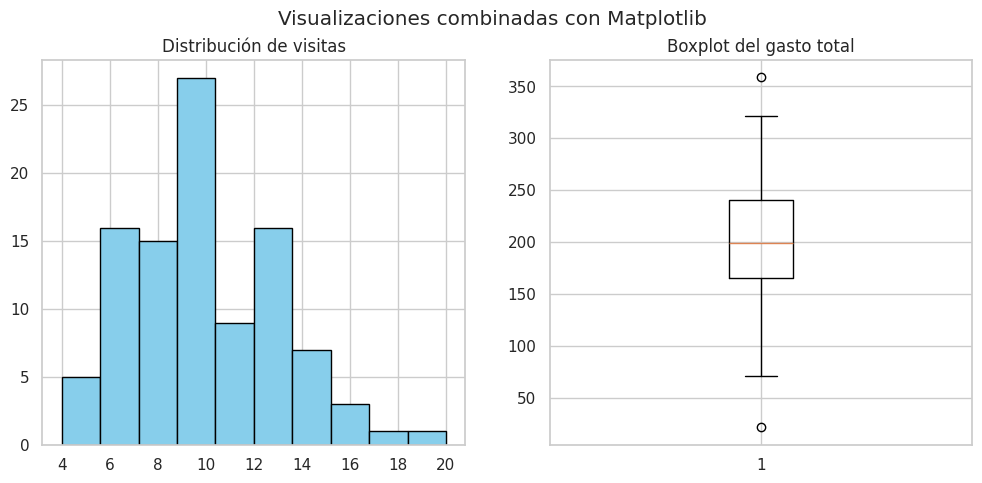

In [ ]:
#Personalización avanzada: subplots

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].hist(df["visitas"], bins=10, color="skyblue", edgecolor="black")
axs[0].set_title("Distribución de visitas")

axs[1].boxplot(df["monto_total"])
axs[1].set_title("Boxplot del gasto total")

plt.suptitle("Visualizaciones combinadas con Matplotlib")
plt.show()


Hallazgos

El uso de Matplotlib permitió crear visualizaciones personalizadas que muestran con claridad distintos aspectos del comportamiento de los clientes.

Los gráficos de líneas, barras, dispersión e histogramas ofrecieron una visión detallada de variables como visitas, compras y gasto total, mientras que los subplots facilitaron la comparación simultánea de distribuciones y patrones.

En conjunto, estos hallazgos refuerzan la importancia de Matplotlib como base para construir representaciones visuales más avanzadas. Su flexibilidad y control sobre cada elemento del gráfico permiten comunicar resultados de manera precisa y profesional, complementando lo aprendido con Seaborn y consolidando la capacidad de presentar datos de forma clara y efectiva.


##Reflexión Final

El proyecto permitió recorrer de manera estructurada las principales etapas del análisis de datos: desde la exploración inicial y la estadística descriptiva, hasta la correlación, regresiones y visualizaciones con Seaborn y Matplotlib. Cada lección aportó herramientas prácticas para comprender mejor el comportamiento de los clientes y comunicar hallazgos de forma clara y profesional.

En conjunto, los resultados muestran que las visitas y compras son factores clave para explicar el gasto, aunque el ajuste de los modelos no siempre fue óptimo, lo que invita a seguir explorando nuevas variables y enfoques. Las visualizaciones reforzaron la interpretación de patrones y diferencias entre segmentos, consolidando la importancia de presentar los datos de manera intuitiva.

Como recomendación final, es fundamental mantener la reproducibilidad del trabajo, documentar cada paso y cuidar la estética de las visualizaciones para una comunicación efectiva de acuerdo a los stakeholders.

